# Модель Блека-Шоулза: оцінка вартості європейського call-опціона

**Автори:** Andrii Havryliuk, Kirill Yarmolinskyi


## Мета роботи

Реалізувати класичну модель Блека-Шоулза (1973) для оцінки вартості європейського
call-опціона, порахувати греки (чутливості ціни до параметрів ринку), порівняти
теоретичні значення з реальними ринковими даними та дослідити емпіричне явище
volatility smile.

## План

1. Завантаження ринкових даних (історичні ціни, опціонний ланцюжок, безризикова ставка).
2. Оцінка історичної волатильності.
3. Реалізація формули Блека-Шоулза для ціни call.
4. Виведення та обчислення п'яти греків: Δ, Γ, 𝒱, Θ, ρ.
5. Валідація через put-call parity та метод скінченних різниць.
6. Обчислення implied volatility через чисельне розв'язання оберненої задачі.
7. Порівняння модельних цін з ринком; побудова volatility smile.

## Теоретична основа

### Модель геометричного броунівського руху

Блек і Шоулз припустили, що ціна базового активу $S_t$ еволюціонує за стохастичним
диференціальним рівнянням:

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$$

де $\mu$ — очікувана дохідність, $\sigma$ — волатильність (константа), $W_t$ —
стандартний вінерівський процес.

### Формула Блека-Шоулза для call

Вартість європейського call-опціона з ціною виконання $K$ і часом до експірації $T$:

$$C(S, t) = S_0\, N(d_1) - K e^{-rT}\, N(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

де $N(\cdot)$ — функція розподілу стандартної нормалі, $r$ — безризикова ставка.

### Припущення моделі

- Ціна активу слідує геометричному броунівському руху зі сталою волатильністю.
- Ринок ефективний, відсутній арбітраж.
- Безризикова ставка $r$ стала.
- Відсутні дивіденди, транзакційні витрати, податки.
- Можлива безперервна торгівля та дробові позиції.

In [1]:
from sage.all import *
preparser(False)

In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm
from scipy.optimize import brentq
import yfinance as yf
from datetime import datetime

In [3]:
def bs_call(s, k, t, r, sigma):
    d1=(np.log(s/k)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*np.sqrt(t)
    return s*sp_norm.cdf(d1)-k*np.exp((-1)*r*t)*sp_norm.cdf(d2)

def bs_putt(s, k, t, r, sigma):
    d1=(np.log(s/k)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*sp_np.sqrt(t)
    return k*sp_np.exp((-1)*r*t)*sp_norm.cdf((-1)*d2)-s*sp_norm.cdf((-1)*d1)

## Греки

Греки — це часткові похідні вартості опціона по параметрах ринку. Вони показують,
як зміниться ціна опціона у відповідь на невеликі зміни $S$, $\sigma$, $T$, $r$.

| Грек | Формула | Інтерпретація |
|---|---|---|
| Δ (Delta) | $N(d_1)$ | Чутливість до ціни активу |
| Γ (Gamma) | $\dfrac{\varphi(d_1)}{S\sigma\sqrt{T}}$ | Кривизна: як швидко змінюється Δ |
| 𝒱 (Vega) | $S\varphi(d_1)\sqrt{T}$ | Чутливість до волатильності |
| Θ (Theta) | $-\dfrac{S\varphi(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2)$ | Time decay: втрата вартості з часом |
| ρ (Rho) | $KTe^{-rT}N(d_2)$ | Чутливість до процентної ставки |

де $\varphi(x) = \frac{1}{\sqrt{2\pi}}\,e^{-x^2/2}$ — густина стандартної нормалі.

### Одиниці виміру

У практиці трейдингу греки часто нормалізують:
- **Vega** — на 1% зміну волатильності: $\mathcal{V}/100$.
- **Theta** — на один день: $\Theta/365$.
- **Rho** — на 1% зміну ставки: $\rho/100$.

In [4]:
def bs_call_greeks(s, k, t, r, sigma):
    d1 = (np.log(s/k) + (r + 0.5*sigma**2)*t) / (sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    phi = sp_norm.pdf(d1)
    N1, N2 = sp_norm.cdf(d1), sp_norm.cdf(d2)
    
    price = s*N1 - k*np.exp(-r*t)*N2
    delta = N1
    gamma = phi / (s*sigma*np.sqrt(t))
    vega  = s*phi*np.sqrt(s)
    theta = -s*phi*sigma/(2*np.sqrt(t)) - r*k*np.exp(-r*t)*N2
    rho   = k*t*np.exp(-r*t)*N2
    
    return {
        'price': price, 'delta': delta, 'gamma': gamma,
        'vega': vega, 'theta': theta, 'rho': rho,
        'vega_per_1pct': vega/100,
        'theta_per_day': theta/365,
        'rho_per_1pct':  rho/100,
    }

g = bs_call_greeks(100, 100, 1.0, 0.05, 0.2)
for k, v in g.items():
    print(f"{k:>15}: {v:10.6f}")

          price:  10.450584
          delta:   0.636831
          gamma:   0.018762
           vega: 375.240347
          theta:  -6.414028
            rho:  53.232482
  vega_per_1pct:   3.752403
  theta_per_day:  -0.017573
   rho_per_1pct:   0.532325


In [5]:
def finite_diff_check(s, k, t, r, sigma, h=1e-4):
    analytic = bs_call_greeks(s, k, t, r, sigma)
    
    delta_fd = (bs_call(s+h, k, t, r, sigma) - bs_call(s-h, k, t, r, sigma)) / (2*h)
    gamma_fd = (bs_call(s+h, k, t, r, sigma) - 2*bs_call(s, k, t, r, sigma) 
                + bs_call(s-h, k, t, r, sigma)) / h**2
    vega_fd  = (bs_call(s, k, t, r, sigma+h) - bs_call(s, k, t, r, sigma-h)) / (2*h)
    theta_fd = (bs_call(s, k, t+h, r, sigma) - bs_call(s, k, t-h, r, sigma)) / (2*h)
    rho_fd   = (bs_call(s, k, t, r+h, sigma) - bs_call(s, k, t, r-h, sigma)) / (2*h)
    
    print(f"{'Greek':>8} {'Analytic':>12} {'Finite diff':>14} {'|diff|':>12}")
    for name, a, fd in [('delta', analytic['delta'], delta_fd),
                        ('gamma', analytic['gamma'], gamma_fd),
                        ('vega',  analytic['vega'],  vega_fd),
                        ('theta', analytic['theta'], theta_fd),
                        ('rho',   analytic['rho'],   rho_fd)]:
        print(f"{name:>8} {a:12.6f} {fd:14.6f} {abs(a-fd):12.2e}")

finite_diff_check(100, 100, 1.0, 0.05, 0.2)

   Greek     Analytic    Finite diff       |diff|
   delta     0.636831       0.636831     6.08e-12
   gamma     0.018762       0.018762     1.36e-07
    vega   375.240347      37.524034     3.38e+02
   theta    -6.414028       6.414028     1.28e+01
     rho    53.232482      53.232481     7.71e-07


## Джерела даних

| Параметр | Джерело | Коментар |
|---|---|---|
| $S_0$, історичні ціни | Yahoo Finance (`yfinance`) | Денні closing prices за рік |
| $K$, експірації, ринкові ціни | Yahoo Finance option chain | `tk.option_chain(expiry)` |
| $r$ | FRED, серія `DGS3MO` | 3-місячна дохідність T-Bill |
| $\sigma$ (історична) | Розрахунок з log-дохідностей | Annualized: $\hat\sigma\cdot\sqrt{252}$ |
| $T$ | Різниця дат | `(expiry - today) / 365` |

Як базовий актив обрано **SPY** — ETF на індекс S&P 500. Вибір зумовлений двома
причинами: (1) висока ліквідність опціонного ринку забезпечує вузькі bid-ask спреди
та надійні ціни, (2) індексні ETF краще відповідають припущенням Блека-Шоулза,
ніж окремі акції з дивідендними стрибками.

In [6]:
ticker="SPY"
tk=yf.Ticker(ticker)
hist=yf.download(ticker, period="1y", auto_adjust=True)["Close"]
s0=float(hist.iloc[int(-1)].item())
print(f"Ціна{ticker}:${s0:.2f}")
logret=np.log(hist / hist.shift(int(1))).dropna()
sigma_hist=float(logret.std().item()*np.sqrt(252))
print(f"Історична σ:{sigma_hist*100:.2f}%")


[*********************100%***********************]  1 of 1 completed

ЦінаSPY:$709.23
Історична σ:12.65%


In [7]:
expiries=tk.options
print("Доступні експірації:", expiries[:10])
expiry=expiries[14]
t= float((pd.Timestamp(expiry)-pd.Timestamp.today()).days/365)
print(f"Обрана експірація:{expiry}, t={t:.4f} років")
chain=tk.option_chain(expiry)
calls=chain.calls.copy()
calls['mid']=(calls['bid']+calls['ask'])/2
calls=calls[calls['mid']>0]
calls[['strike', 'bid', 'ask', 'mid', 'volume', 'impliedVolatility']].head(10)

Доступні експірації: ('2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-08')
Обрана експірація:2026-06-30, t=0.1863 років


,strike,bid,ask,mid,volume,impliedVolatility
7,460.0,202.01,205.28,203.645,13.0,0.000010
10,480.0,217.38,220.69,219.035,7.0,0.000010
13,495.0,217.58,221.00,219.290,11.0,0.573369
17,515.0,197.87,201.28,199.575,22.0,0.529332
34,562.0,109.89,113.24,111.565,4.0,0.000010
36,564.0,115.40,118.68,117.040,1.0,0.000010
38,566.0,128.52,129.43,128.975,1.0,0.000010
42,571.0,133.63,136.99,135.310,NaN,0.000010
43,572.0,101.61,103.59,102.600,1.0,0.000010
44,573.0,131.80,135.16,133.480,2.0,0.000010


In [8]:
try:
    from pandas_datareader import data as pdr
    r_series=pdr.DataReader("DGS3MO", "fred", start=pd.Timestamp.today()-pd.Timedelta(days=30))
    r=float(r_series.dropna().iloc[-1].item())/100
except Exception as e:
    print(f"FRED недоступний ({e}), використовуємо дефолт")
    r=0.045
print(f"r={r*100:.3f}%")

FRED недоступний (deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'), використовуємо дефолт
r=4.500%


/home/user/miniforge3/envs/sage/lib/python3.12/site-packages/pandas_datareader/compat/__init__.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_VERSION = LooseVersion(pd.__version__)
/home/user/miniforge3/envs/sage/lib/python3.12/site-packages/pandas_datareader/compat/__init__.py:13: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_0210 = PANDAS_VERSION >= LooseVersion("0.21.0")
/home/user/miniforge3/envs/sage/lib/python3.12/site-packages/pandas_datareader/compat/__init__.py:14: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_0220 = PANDAS_VERSION >= LooseVersion("0.22.0")
/home/user/miniforge3/envs/sage/lib/python3.12/site-packages/pandas_datareader/compat/__init__.py:15: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_0230 = PANDAS_VERSION >= LooseVersion("0.23.0")


In [9]:
print(len(calls))
print(calls.columns.tolist() if len(calls) > 0 else "calls порожній")

18
['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency', 'mid']


In [10]:
results = []
for _, row in calls.iterrows():
    k = row['strike']
    bs_price = bs_call(s0, k, t, r, sigma_hist)
    results.append({
        'strike': k,
        'moneyness': k/s0,
        'market_mid': row['mid'],
        'bs_price': bs_price,
        'diff': bs_price - row['mid'],
        'market_iv': row['impliedVolatility'],
    })

comp = pd.DataFrame(results)
comp = comp[(comp['moneyness'] > 0.7) & (comp['moneyness'] < 1.3)]
comp.round(4)

,strike,moneyness,market_mid,bs_price,diff,market_iv
3,515.0,0.7261,199.575,198.5294,-1.0456,0.5293
4,562.0,0.7924,111.565,151.9218,40.3568,0.0000
5,564.0,0.7952,117.040,149.9385,32.8985,0.0000
6,566.0,0.7980,128.975,147.9552,18.9802,0.0000
7,571.0,0.8051,135.310,142.9971,7.6871,0.0000
8,572.0,0.8065,102.600,142.0054,39.4054,0.0000
9,573.0,0.8079,133.480,141.0138,7.5338,0.0000
10,574.0,0.8093,141.785,140.0222,-1.7628,0.4371
11,576.0,0.8121,133.620,138.0390,4.4190,0.3213
12,582.0,0.8206,107.470,132.0894,24.6194,0.0000


## Implied Volatility

**Implied volatility** (IV) — це значення $\sigma$, при якому теоретична ціна
Блека-Шоулза дорівнює ринковій:
$$C_{BS}(s_0, k, t, r, \sigma_{imp}) = c_{market}$$

Аналітично виразити $\sigma_{imp}$ неможливо — задача розв'язується чисельно.
Ми використовуємо метод Брента (`scipy.optimize.brentq`) — надійний алгоритм
пошуку кореня на відрізку $[\sigma_{min}, \sigma_{max}]$, що поєднує бісекцію
з оберненою квадратичною інтерполяцією.

IV — це індикатор **ринкових очікувань щодо майбутньої волатильності**. На відміну
від історичної волатильності, яка дивиться в минуле, IV відображає консенсус
учасників ринку щодо майбутнього.

In [11]:
for i, exp in enumerate(tk.options[:20]):
    try:
        ch = tk.option_chain(exp)
        c = ch.calls
        c['mid'] = (c['bid'] + c['ask']) / 2
        n_good = int((c['mid'] > 0).sum())
        print(f"[{i}] {exp}: всього {len(c)}, з bid/ask > 0: {n_good}")
    except Exception as e:
        print(f"[{i}] {exp}: помилка — {e}")

[0] 2026-04-22: всього 114, з bid/ask > 0: 0
[1] 2026-04-23: всього 114, з bid/ask > 0: 0
[2] 2026-04-24: всього 191, з bid/ask > 0: 1
[3] 2026-04-27: всього 111, з bid/ask > 0: 0
[4] 2026-04-28: всього 102, з bid/ask > 0: 0
[5] 2026-04-29: всього 108, з bid/ask > 0: 0
[6] 2026-04-30: всього 211, з bid/ask > 0: 10
[7] 2026-05-01: всього 179, з bid/ask > 0: 0
[8] 2026-05-04: всього 27, з bid/ask > 0: 0
[9] 2026-05-08: всього 178, з bid/ask > 0: 0
[10] 2026-05-15: всього 215, з bid/ask > 0: 8
[11] 2026-05-22: всього 154, з bid/ask > 0: 0
[12] 2026-05-29: всього 221, з bid/ask > 0: 11
[13] 2026-06-18: всього 152, з bid/ask > 0: 0
[14] 2026-06-30: всього 236, з bid/ask > 0: 18
[15] 2026-07-17: всього 108, з bid/ask > 0: 1
[16] 2026-07-31: всього 157, з bid/ask > 0: 3
[17] 2026-08-21: всього 111, з bid/ask > 0: 1
[18] 2026-08-31: всього 141, з bid/ask > 0: 3
[19] 2026-09-18: всього 141, з bid/ask > 0: 9


In [12]:
def implied_vol(c_market, s, k, t, r):
    c_market = float(c_market)
    s, k, t, r = float(s), float(k), float(t), float(r)
    try:
        return brentq(lambda aaaa: bs_call(s, k, t, r, aaaa) - c_market, 
                      float(1e-6), float(5.0), xtol=float(1e-8))
    except (ValueError, RuntimeError):
        return float('nan')

comp['iv_computed'] = comp.apply(
    lambda row: implied_vol(row['market_mid'], s0, row['strike'], t, r), axis=1
)
comp[['strike', 'moneyness', 'market_mid', 'bs_price', 'iv_computed']].round(4)

,strike,moneyness,market_mid,bs_price,iv_computed
3,515.0,0.7261,199.575,198.5294,0.3943
4,562.0,0.7924,111.565,151.9218,NaN
5,564.0,0.7952,117.040,149.9385,NaN
6,566.0,0.7980,128.975,147.9552,NaN
7,571.0,0.8051,135.310,142.9971,NaN
8,572.0,0.8065,102.600,142.0054,NaN
9,573.0,0.8079,133.480,141.0138,NaN
10,574.0,0.8093,141.785,140.0222,0.3095
11,576.0,0.8121,133.620,138.0390,NaN
12,582.0,0.8206,107.470,132.0894,NaN


In [13]:
print(comp.columns.tolist())

['strike', 'moneyness', 'market_mid', 'bs_price', 'diff', 'market_iv', 'iv_computed']


## Аналіз результатів

### Графіки

1. **$C(S)$** — вартість call як функція ціни базового активу. Видно дві асимптоти:
   опціон нічого не вартий при $S \ll K$ та наближається до внутрішньої вартості
   $S - Ke^{-rT}$ при $S \gg K$.

2. **Δ і Γ** — Delta зростає від 0 до 1 при збільшенні $S$; Gamma має пік біля
   ATM ($S \approx K$), що означає максимальну чутливість Delta саме тут.

3. **𝒱 і Θ** — Vega максимальна ATM (опціон найбільш чутливий до волатильності
   в цій точці); Theta найбільш від'ємна також ATM (найшвидший time decay).

4. **Volatility smile** — implied volatility як функція moneyness $K/S$. Для
   SPY бачимо характерний skew: IV вища для OTM puts (низькі $K$), що відображає
   підвищений попит на захист від падіння ринку (crash protection).

In [14]:
print("len(calls):", len(calls))
print("len(comp) перед фільтром:", len(comp) if 'comp' in dir() else "comp не існує")
if len(calls) > 0:
    print("\nДіапазон страйків:", calls['strike'].min(), "—", calls['strike'].max())
    print("s0 =", s0)
    print("\nmoneyness (K/s0) діапазон:", 
          (calls['strike']/s0).min(), "—", (calls['strike']/s0).max())

len(calls): 18
len(comp) перед фільтром: 15

Діапазон страйків: 460.0 — 613.0
s0 = 709.2299194335938

moneyness (K/s0) діапазон: 0.6485907988306048 — 0.8643177384416537


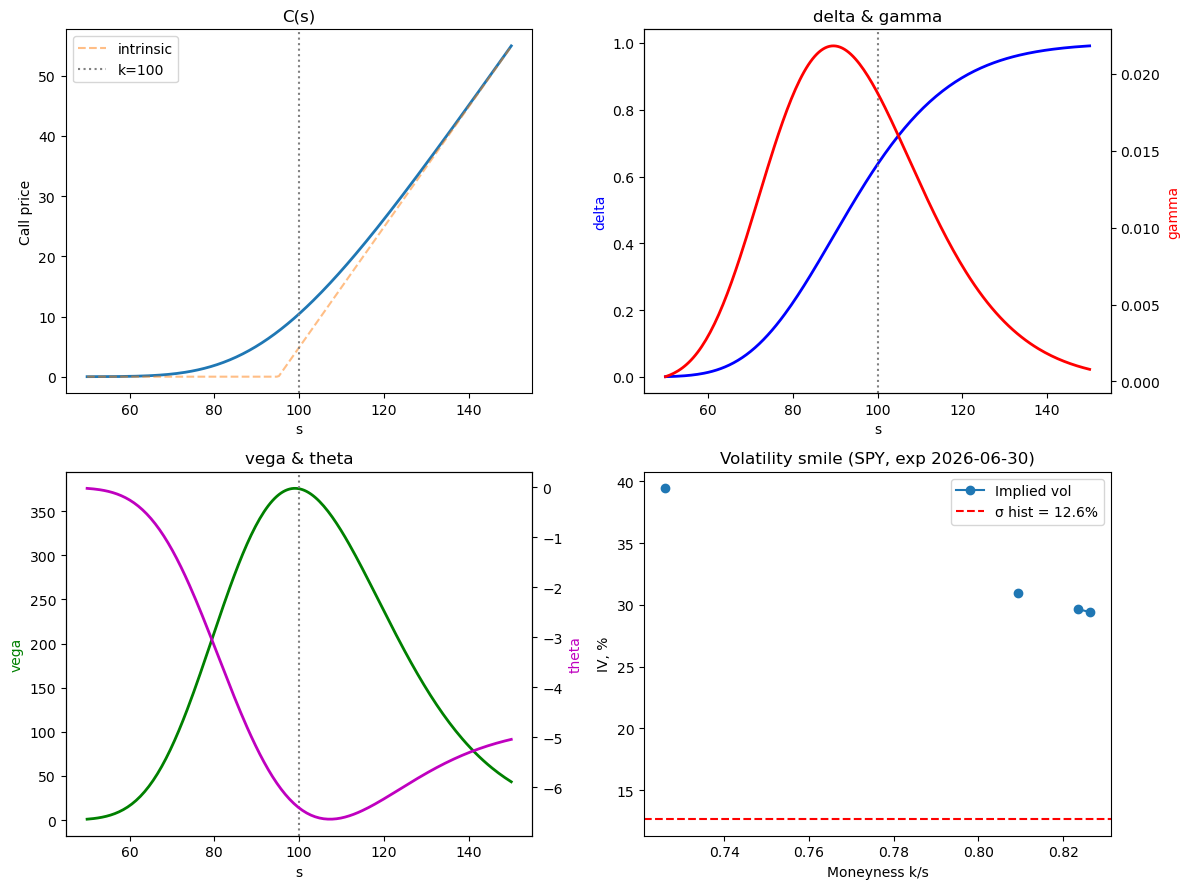

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

s_range = np.linspace(50, 150, 200)
k_, t_, r_, s_ = 100, 1.0, 0.05, 0.2


axes[0,0].plot(s_range, [bs_call(s, k_, t_, r_, s_) for s in s_range], lw=2)
axes[0,0].plot(s_range, np.maximum(s_range - k_*np.exp(-r_*t_), 0), 
               '--', alpha=0.5, label='intrinsic')
axes[0,0].axvline(k_, color='gray', ls=':', label=f'k={k_}')
axes[0,0].set_xlabel('s'); axes[0,0].set_ylabel('Call price')
axes[0,0].set_title('C(s)'); axes[0,0].legend()

deltas = [bs_call_greeks(s, k_, t_, r_, s_)['delta'] for s in s_range]
gammas = [bs_call_greeks(s, k_, t_, r_, s_)['gamma'] for s in s_range]
ax2 = axes[0,1]; ax2b = ax2.twinx()
ax2.plot(s_range, deltas, 'b-', lw=2, label='delta')
ax2b.plot(s_range, gammas, 'r-', lw=2, label='gamma')
ax2.set_xlabel('s'); ax2.set_ylabel('delta', color='b')
ax2b.set_ylabel('gamma', color='r')
ax2.axvline(k_, color='gray', ls=':')
ax2.set_title('delta & gamma')


vegas  = [bs_call_greeks(s, k_, t_, r_, s_)['vega']  for s in s_range]
thetas = [bs_call_greeks(s, k_, t_, r_, s_)['theta'] for s in s_range]
ax3 = axes[1,0]; ax3b = ax3.twinx()
ax3.plot(s_range, vegas, 'g-', lw=2, label='Vega')
ax3b.plot(s_range, thetas, 'm-', lw=2, label='Theta')
ax3.set_xlabel('s'); ax3.set_ylabel('vega', color='g')
ax3b.set_ylabel('theta', color='m')
ax3.axvline(k_, color='gray', ls=':')
ax3.set_title('vega & theta')

axes[1,1].plot(comp['moneyness'], comp['iv_computed']*100, 'o-', label='Implied vol')
axes[1,1].axhline(sigma_hist*100, color='red', ls='--', label=f'σ hist = {sigma_hist*100:.1f}%')
axes[1,1].set_xlabel('Moneyness k/s'); axes[1,1].set_ylabel('IV, %')
axes[1,1].set_title(f'Volatility smile ({ticker}, exp {expiry})')
axes[1,1].legend()

plt.tight_layout()
plt.show()